# Assignment 1: Breast Cancer Classification

Author: Tobias Beekmans  
Master ICT – Software Engineering  
DataOps Specialisation Project – Individual Assignment  
Submission Date: 15.03.2026

In [59]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

In [60]:
data_dir = Path("../data/processed")

X_train = pd.read_csv(data_dir / "X_train_scaled.csv")
X_test = pd.read_csv(data_dir / "X_test_scaled.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")

In [61]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 5. Evaluation

According to the CRISP-DM methodology, the evaluation phase examines whether the developed models achieve the objectives defined in the earlier project phases. [1]

The evaluation focuses on comparing the predictive performance of the trained models, analyzing classification errors, and selecting the most appropriate final model for breast cancer classification. Particular attention is given to the medical relevance of different error types, since incorrectly classifying a malignant tumour as benign may have more serious consequences than the opposite error.


## 5.1 Evaluation Objectives

The purpose of this evaluation phase is to determine whether the trained models satisfy the objectives defined during the business understanding and modeling phases, and to identify the model that provides the most suitable balance between predictive performance and interpretability.

In a medical classification context, evaluation should not rely on accuracy alone. It is also important to assess how well the models identify malignant tumours, because false negatives are particularly critical (a malignant case incorrectly predicted as benign may delay further diagnostic procedures or treatment).

For this reason the evaluation considers confusion matrices, ROC curves, and AUC values in addition to the performance metrics reported in the modeling phase.

In [62]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

## 5.2 Confusion Matrix

The following confusion matrices illustrate the classification results of the evaluated models on the test dataset.

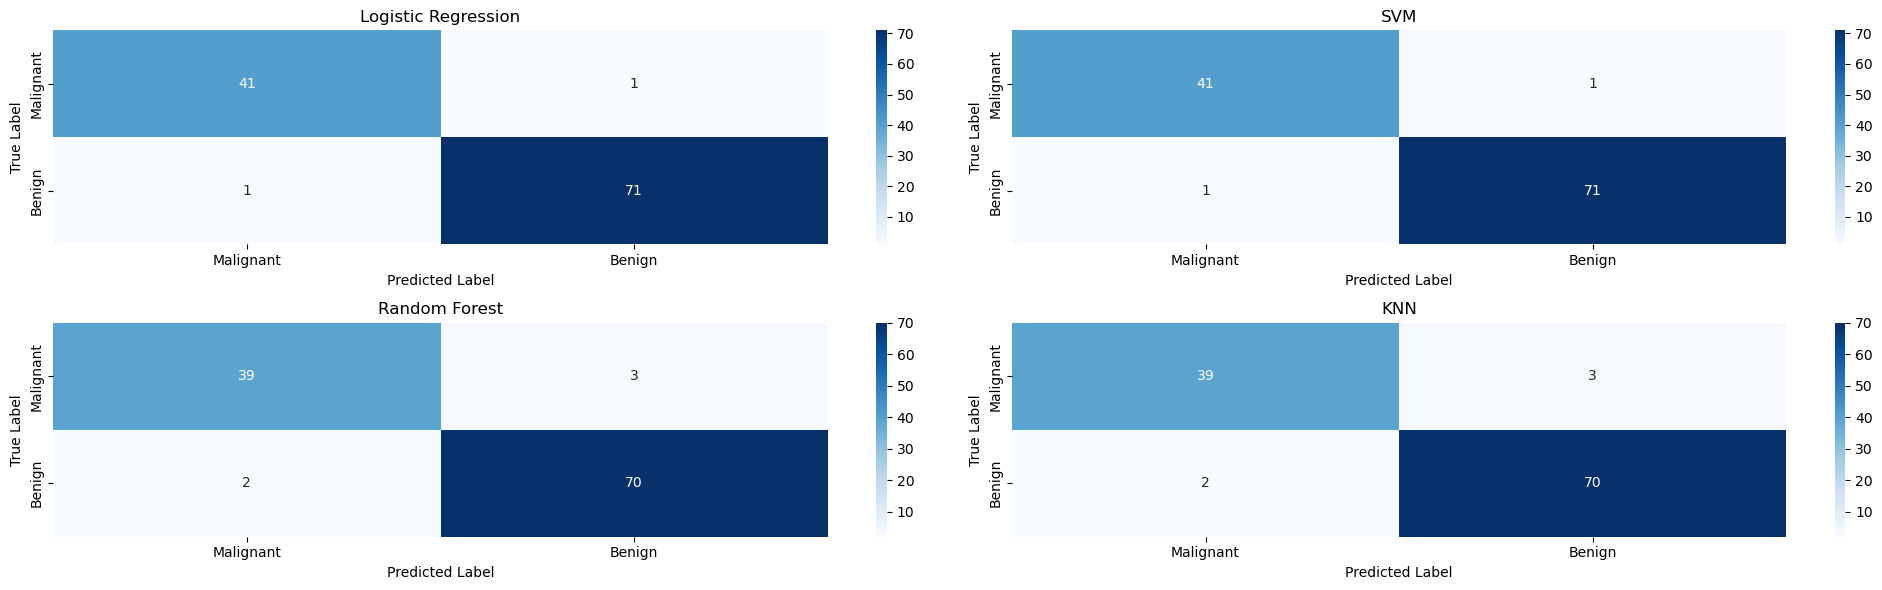

In [63]:
fig, axes = plt.subplots(2,2, figsize=(20,6))

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"],
    ax=axes[0,0]
)
axes[0,0].set_title("Logistic Regression")
axes[0,0].set_xlabel("Predicted Label")
axes[0,0].set_ylabel("True Label")

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"],
    ax=axes[0,1]
)
axes[0,1].set_title("SVM")
axes[0,1].set_xlabel("Predicted Label")
axes[0,1].set_ylabel("True Label")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"],
    ax=axes[1,0]
)
axes[1,0].set_title("Random Forest")
axes[1,0].set_xlabel("Predicted Label")
axes[1,0].set_ylabel("True Label")

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"],
    ax=axes[1,1]
)
axes[1,1].set_title("KNN")
axes[1,1].set_xlabel("Predicted Label")
axes[1,1].set_ylabel("True Label")

plt.tight_layout()
plt.show()


Logistic Regression and Support Vector Machine show the strongest confusion matrix results. Both models correctly classify 41 of 42 malignant cases and 71 of 72 benign cases, resulting in only one false negative and one false positive each. This indicates that both models make very few classification errors overall and perform very reliably on the test dataset.

As previously stated, false negatives are particularly critical because they represent malignant tumours that are incorrectly classified as benign. Logistic Regression and SVM each produce only one false negative, which is the most favourable result among the evaluated models.

Random Forest and K-Nearest Neighbours also perform well, but both models produce more errors. Each of them misclassifies 3 malignant tumours as benign and 2 benign tumours as malignant. Although Random Forest and KNN still achieve high overall accuracy, their higher number of false negatives makes them less suitable than Logistic Regression and SVM for a diagnostic support setting in which missing malignant cases should be minimized.

The confusion matrix analysis confirms that Logistic Regression and SVM provide the most reliable classification behaviour, especially with regard to minimizing clinically undesirable false negatives.

## 5.3 ROC Curve and AUC

The receiver operating characteristic (ROC) curves compare how well the evaluated models distinguish between malignant and benign tumour cases across different classification thresholds. A model with a curve closer to the upper-left corner achieves a better balance between a high true positive rate and a low false positive rate.

The area under the ROC curve (AUC) summarizes this discrimination ability in a single value. Higher AUC values indicate stronger overall class separability.


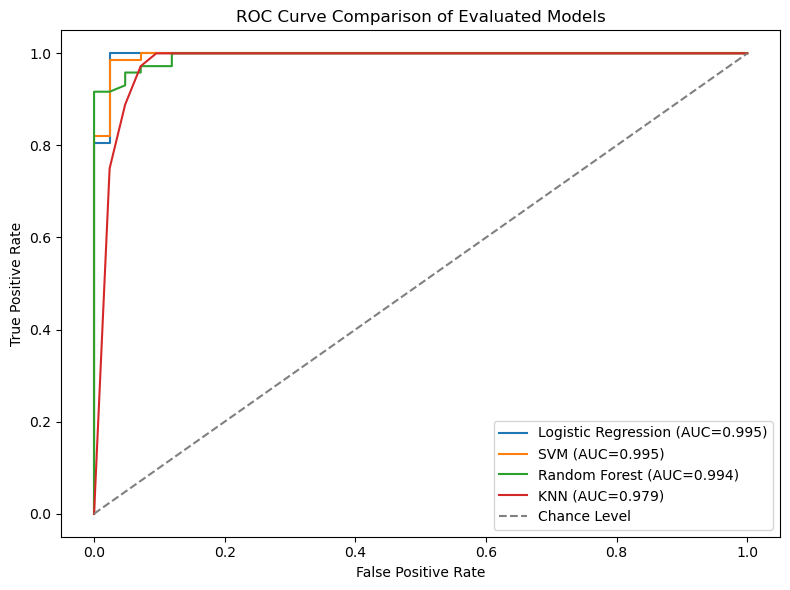

In [64]:
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_svm = svm_model.predict_proba(X_test)[:,1]
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={auc_log:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="grey", label="Chance Level")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Evaluated Models")

plt.legend()
plt.tight_layout()
plt.show()


Logistic Regression and Support Vector Machine achieve the strongest ROC performance, both reaching an AUC value of approximately 0.995. Their ROC curves remain very close to the upper-left corner of the plot, indicating discrimination between malignant and benign tumour cases across different classification thresholds.

Random Forest shows a very similar performance with an AUC of approximately 0.994. Although its ROC curve lies slightly below those of Logistic Regression and SVM, the difference is minimal and still indicates very strong classification capability.

K-Nearest Neighbours performs somewhat worse than the other models, with an AUC of approximately 0.979. While this still represents strong discrimination ability, its ROC curve rises more gradually, indicating slightly weaker separation between the two classes.

The very high AUC values across all models suggest that the diagnostic features extracted from the breast cell nuclei provide strong predictive information for distinguishing malignant and benign tumours.

The ROC analysis confirms the findings from the confusion matrix and the performance metrics reported in the modeling phase. Logistic Regression and SVM consistently achieve the strongest classification performance, while Random Forest and KNN remain slightly less effective but still highly accurate classifiers for this dataset.

## 5.4 Assessment Against Objectives / Research Questions

The evaluation results indicate that the objectives defined during the business understanding phase have been successfully achieved.

**Business Objectives:**  
The analysis demonstrates that machine learning methods can effectively support the classification of breast tumour samples (BO1). All evaluated models achieve very high predictive performance on the test dataset, indicating that the diagnostic features provide strong predictive signals for distinguishing between malignant and benign tumours. In addition, the exploratory data analysis conducted during the data understanding phase identified several features that show strong relationships with the diagnostic outcome, contributing to a better understanding of relevant tumour characteristics (BO2). The full workflow was implemented using structured Jupyter notebooks and a reproducible Python environment, fulfilling the objective of creating a transparent and reproducible analysis process (BO3).

**Data Mining Goals:**  
The data mining goals defined for this project were also successfully addressed. The dataset was systematically explored and analysed during the data understanding phase (DMG1), followed by data cleaning and preprocessing steps that prepared the dataset for modelling (DMG2). Several classical machine learning models were trained and compared during the modelling phase (DMG3), and the evaluation phase identified the most suitable model for the classification task based on multiple performance metrics (DMG4).

**Research Questions:**  
The research questions guiding this project can be answered based on the obtained results. First, the exploratory analysis identified diagnostic features related to tumour size and boundary irregularity as particularly informative predictors of tumour diagnosis (RQ1). Second, the modelling and evaluation results show that classical machine learning models can classify breast tumours with very high accuracy on this dataset (RQ2). Third, Logistic Regression and Support Vector Machine achieved the strongest predictive performance, with Logistic Regression ultimately selected as the final model due to its strong performance and higher interpretability (RQ3).

The evaluation confirms that the developed machine learning workflow successfully addresses the objectives defined at the beginning of the project and provides a reliable approach for breast cancer classification using the Wisconsin Breast Cancer dataset.

## 5.5 Final Model Selection

Both Logistic Regression and Support Vector Machine achieved the strongest predictive performance across the evaluation metrics. The confusion matrix analysis showed that both models correctly classified almost all tumour cases and produced only one false negative each. In addition, both models achieved the highest AUC values in the ROC analysis, indicating excellent discrimination between malignant and benign cases.

Since the predictive performance of Logistic Regression and SVM is nearly identical, the final model selection focuses on model interpretability and simplicity. Logistic Regression provides a more transparent modelling approach because the relationship between the input features and the predicted outcome can be examined through the model coefficients. This makes the model behaviour easier to interpret and explain.

The cross-validation results obtained during the modelling phase further support the stability of the Logistic Regression model across different training subsets.

In medical decision-support contexts, model transparency can be particularly important because clinicians may require insight into how predictions are generated. For this reason, Logistic Regression provides a favourable balance between predictive performance and interpretability.

Considering these factors, Logistic Regression is selected as the most suitable model for the breast cancer classification task in this project.

## 5.6 Limitations

Although the results of this project demonstrate very strong classification performance, several limitations should be considered when interpreting the findings.

First, the dataset used in this study is relatively small, containing only 569 observations. While cross-validation and a separate test set were used to mitigate overfitting, models trained on small datasets may still be sensitive to variations in the data distribution.

Second, the analysis relies exclusively on the Wisconsin Breast Cancer dataset. The evaluation therefore reflects the model performance on this specific dataset, but it does not guarantee that the same results would be obtained on other clinical datasets. External validation using additional datasets would be necessary to assess the generalisability of the models.

Third, several diagnostic features in the dataset show strong correlations. While this did not negatively affect predictive performance, high feature correlations may influence model stability or interpretability in some modelling approaches.

Finally, the modelling phase focused on comparing several classical machine learning algorithms using standard parameter configurations. More extensive hyperparameter tuning, feature selection, or dimensionality reduction techniques such as principal component analysis (PCA) could potentially further improve model performance, but were outside the scope of this assignment.

Some related studies also explore feature selection or dimensionality reduction methods to improve model efficiency and reduce redundancy among highly correlated variables.

## 5.7 Future Work

Several extensions could further improve and extend the analysis conducted in this project.

First, future studies could evaluate the trained models on additional breast cancer datasets in order to assess their generalisability across different data sources and clinical settings.

Second, further research could investigate the impact of feature selection or dimensionality reduction techniques such as principal component analysis (PCA). These approaches may help reduce redundancy among highly correlated diagnostic features and potentially improve model efficiency.

Finally, more extensive hyperparameter optimisation could be explored to further refine the performance of the evaluated machine learning models. While the present study focused on standard parameter settings to maintain methodological clarity, systematic tuning strategies could provide additional performance improvements.

## References

[1] IBM Corporation (2011): *IBM SPSS Modeler CRISP-DM Guide*

[2] Müller, A. C.; Guido, S. (2016): *Introduction to Machine Learning with Python*

[3] Rovshenov, A.; Peker, S. (2022): *Performance Comparison of Different Machine Learning Techniques for Early Prediction of Breast Cancer using Wisconsin Breast Cancer Dataset*